## 1. Paths and imports


# TabPFN FP follow-up (VLST): ratio sweep + dual evaluation matrices

1. Loads **VLST** + union **`false_positives_union_test.csv`**; aligns features. **By default drops** `NO.` and `Name` (`VLST_DROP_ROW_ID_COLS` — set to `0` / `false` / `no` to keep). Those columns often yield **AUC ≈ 1** (row memorization).
2. **Fixed train core** (every ratio): **80% of positives** + **all train FPs** (80% of union CSV; works for any union size). Per ratio **r**, add TNs until **`92×r` negatives** (train FPs count first). Ratios = **1**, then **5, 10, …**, **plus `max_r`** if needed, then optional **full_pool**.
3. **split_b built first** (size = **`HOLDOUT_FRAC` × N**): **20% of positives** (fixed train/test counts) + **20% of union FPs** (capped if the FP file is huge) + **true negatives** to fill the rest. **Train** = remaining positives + remaining FPs + TNs (disjoint from split_b). Then **60/20/20** on the cohort; **split_a** = cohort holdout.
4. **Thresholds** (printed + CSV): **0.5** · **val→F0.5/F1/F2** · **hold→F0.5/F1/F2*** (holdout oracle).
5. **§5** curves (F-score, FP/FN, ROC/PR-AUC): validation, split_a holdout, split_b@val-t, split_b oracle (see §5 table).
6. **`fp_followup_ratio_sweep.csv`**, §4 scrollable table when IPython is available.

**Backend:** `tabpfn-client` (cloud).

**Env:** `VLST_FULL_DATA_PATH`, `VLST_FP_OUTPUT_DIR`, `TABPFN_TOKEN` (or Kaggle secret **`TABPFN_TOKEN_H`**), `VLST_TABPFN_FOLLOWUP_SEED`, `VLST_DROP_ROW_ID_COLS`, `TABPFN_N_ESTIMATORS`, `VLST_FP_FOLLOWUP_HOLDOUT_FRAC` (split_b size, default `0.2`), `VLST_FP_FOLLOWUP_POS_HOLDOUT_FRAC`, `VLST_FP_FOLLOWUP_FP_HOLDOUT_FRAC`, optional `VLST_UNION_ROW_ID_MODE` (`auto` / `holdout_position` / `full_table_row`).



In [1]:
import os
import warnings

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = int(os.environ.get("VLST_TABPFN_FOLLOWUP_SEED", "42"))

FULL_DATA_PATH = os.environ.get(
    "VLST_FULL_DATA_PATH",
    "/kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv",
)


def pick_output_dir_modeling_fp() -> str:
    out = os.environ.get("VLST_FP_FOLLOWUP_OUT_DIR")
    if out:
        return os.path.expanduser(out.rstrip(os.sep))
    if os.path.isdir("/kaggle/working"):
        return "/kaggle/working/vlst_fp_followup_output"
    return os.path.normpath(os.path.join("..", "..", "data", "result", "modeling_fp"))


OUTPUT_DIR = pick_output_dir_modeling_fp()
os.makedirs(OUTPUT_DIR, exist_ok=True)


def pick_fp_mining_output_dir() -> str:
    out = os.environ.get("VLST_FP_OUTPUT_DIR") or os.environ.get("VLST_FP_MINING_OUT")
    if not out:
        kaggle_fp_out = "/kaggle/input/datasets/amirmahdidaraei/fp-output/vlst_fp_mining_output"
        if os.path.isdir(kaggle_fp_out):
            out = kaggle_fp_out
    if out:
        out = os.path.expanduser(out.rstrip(os.sep))
    elif os.path.isdir("/kaggle/working"):
        out = "/kaggle/working/vlst_fp_mining_output"
    else:
        repo_modeling_fp = os.path.normpath(
            os.path.join("..", "..", "data", "result", "modeling_fp")
        )
        if os.path.isfile(os.path.join(repo_modeling_fp, "false_positives_union_test.csv")):
            out = repo_modeling_fp
        else:
            out = os.path.normpath(
                os.path.join("..", "..", "data", "result", "modeling_advanced", "fp_mining")
            )
    tag = os.environ.get("VLST_FP_RUN_TAG", "").strip()
    if tag:
        out = os.path.join(out, tag)
    return out


FP_MINING_OUT = pick_fp_mining_output_dir()
UNION_CSV = os.path.join(FP_MINING_OUT, "false_positives_union_test.csv")

print("FULL_DATA_PATH:", FULL_DATA_PATH)
print("Follow-up artifacts dir (OUTPUT_DIR):", OUTPUT_DIR)
print("FP mining outputs (union CSV):", FP_MINING_OUT)
print("Union CSV:", UNION_CSV)


FULL_DATA_PATH: /kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv
Follow-up artifacts dir (OUTPUT_DIR): /kaggle/working/vlst_fp_followup_output
FP mining outputs (union CSV): /kaggle/input/datasets/amirmahdidaraei/fp-output/vlst_fp_mining_output
Union CSV: /kaggle/input/datasets/amirmahdidaraei/fp-output/vlst_fp_mining_output/false_positives_union_test.csv


In [2]:
!pip install -U tabpfn-client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.6/46.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 254.6/254.6 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.
google-colab 1.0.0 requires requests==

In [3]:
from tabpfn_client import set_access_token

_KAGGLE_SECRET_NAME = "TABPFN_TOKEN_H"

_token = os.environ.get("TABPFN_TOKEN", "").strip()
if not _token:
    _token = os.environ.get("TABPFN_TOKEN_H", "").strip()
if not _token:
    try:
        from kaggle_secrets import UserSecretsClient

        _token = str(UserSecretsClient().get_secret(_KAGGLE_SECRET_NAME)).strip()
    except Exception:
        pass

if _token:
    os.environ["TABPFN_TOKEN"] = _token  # downstream cells read TABPFN_TOKEN
    set_access_token(_token)
    print("TabPFN client: access token configured (value hidden).")
else:
    print(
        f"Set TABPFN_TOKEN / TABPFN_TOKEN_H (env) or Kaggle secret {_KAGGLE_SECRET_NAME!r} before §3. "
        "Get a key at https://ux.priorlabs.ai/account"
    )


TabPFN client: access token configured (value hidden).


## 2. Load data, align features, train/test pools, ratio schedule


In [4]:
if not os.path.isfile(FULL_DATA_PATH):
    raise FileNotFoundError(
        f"Missing full dataset at {FULL_DATA_PATH}. Set VLST_FULL_DATA_PATH before running."
    )
if not os.path.isfile(UNION_CSV):
    raise FileNotFoundError(
        f"Missing {UNION_CSV}. Run fp mining export first or set VLST_FP_OUTPUT_DIR / VLST_FP_RUN_TAG."
    )

df_full = pd.read_csv(FULL_DATA_PATH, low_memory=False)
df_union = pd.read_csv(UNION_CSV, low_memory=False)
if "test_row_id" not in df_union.columns:
    raise ValueError("Union CSV must contain test_row_id.")


def _norm_col(s: str) -> str:
    return "".join(ch.lower() for ch in str(s).strip() if ch.isalnum())


col_map = {_norm_col(c): c for c in df_full.columns}

forced_target = os.environ.get("VLST_FULLDATA_TARGET_COL", "").strip()
if forced_target:
    fk = _norm_col(forced_target)
    if fk not in col_map:
        raise ValueError(
            f"VLST_FULLDATA_TARGET_COL={forced_target!r} not found. "
            f"Available columns include: {list(df_full.columns)[:12]} ..."
        )
    target_col = col_map[fk]
else:
    preferred = [
        "Stent thrombosis",
        "stent_thrombosis",
        "StentThrombosis",
        "target",
        "label",
        "y",
        "class",
        "Outcome",
        "VLST",
    ]
    target_col = None
    for c in preferred:
        k = _norm_col(c)
        if k in col_map:
            cand = col_map[k]
            vals = set(
                pd.to_numeric(df_full[cand], errors="coerce")
                .dropna()
                .astype(int)
                .unique()
                .tolist()
            )
            if vals.issubset({0, 1}) and len(vals) >= 1:
                target_col = cand
                break
    if target_col is None:
        raise ValueError(
            "Could not confidently infer target column. "
            "Set VLST_FULLDATA_TARGET_COL='Stent thrombosis' (or your label column name)."
        )

print("Using target column from full data:", target_col)

y_full = pd.to_numeric(df_full[target_col], errors="coerce").fillna(0).astype(int).to_numpy()
if not set(np.unique(y_full)).issubset({0, 1}):
    raise ValueError("Target column must be binary (0/1).")

X_full_df = df_full.drop(columns=[target_col]).copy()

_drop_ids = os.environ.get("VLST_DROP_ROW_ID_COLS", "1").strip().lower() not in (
    "0",
    "false",
    "no",
)
if _drop_ids:
    _id_cols = [c for c in ("NO.", "Name") if c in X_full_df.columns]
    if _id_cols:
        X_full_df = X_full_df.drop(columns=_id_cols)
        print("Dropped row-identifier columns from features:", _id_cols)


def _norm_name(s: str) -> str:
    return "".join(ch.lower() for ch in str(s) if ch.isalnum())


_drop_norm = {
    _norm_name("Time since stent implantation"),
    _norm_name("time_since_implantation"),
    _norm_name("time since implantation"),
}
_drop_cols = [c for c in X_full_df.columns if _norm_name(c) in _drop_norm]
if _drop_cols:
    X_full_df = X_full_df.drop(columns=_drop_cols)
    print("Dropped leakage-style feature(s):", _drop_cols)

for c in X_full_df.columns:
    X_full_df[c] = pd.to_numeric(X_full_df[c], errors="coerce")

meta_cols = {
    "test_row_id",
    "y_true",
    "p_winner",
    "p_tabpfn",
    "fp_winner",
    "fp_tabpfn_legacy_t",
    "fp_tabpfn_any_grid_t",
    "source",
    "threshold",
}
shared_features = [c for c in X_full_df.columns if c not in meta_cols]
if not shared_features:
    raise ValueError("No feature columns in full dataset after exclusions.")

_union_feat = [c for c in df_union.columns if c not in meta_cols]
union_only_cols = [c for c in _union_feat if c not in X_full_df.columns]
if union_only_cols:
    print(
        "Note: union CSV has",
        len(union_only_cols),
        "feature column(s) not in full data (omitted from training schema); examples:",
        union_only_cols[:12],
    )

X_full_use = X_full_df[shared_features].copy()
X_union_use = df_union.reindex(columns=shared_features)
for c in shared_features:
    X_union_use[c] = pd.to_numeric(X_union_use[c], errors="coerce")

med = X_full_use.median(numeric_only=True)
X_full_use = X_full_use.fillna(med)
X_union_use = X_union_use.fillna(med)

assert (
    X_full_use.shape[1] == len(shared_features) == X_union_use.shape[1]
), (X_full_use.shape[1], len(shared_features), X_union_use.shape[1])

rng = np.random.RandomState(RANDOM_STATE)
pos_idx = np.flatnonzero(y_full == 1)
tn_pool_idx = np.flatnonzero(y_full == 0)
if pos_idx.size == 0:
    raise ValueError("No positives in full dataset.")

# Notebook-owned splits on full VLST (no data/processed train|test).
HOLDOUT_FRAC = float(
    os.environ.get(
        "VLST_FP_FOLLOWUP_HOLDOUT_FRAC",
        os.environ.get("VLST_PREPROCESS_TEST_SIZE", "0.2"),
    )
)
SPLIT_SEED = int(os.environ.get("VLST_FP_FOLLOWUP_SPLIT_SEED", str(RANDOM_STATE)))
POS_HOLDOUT_FRAC = float(os.environ.get("VLST_FP_FOLLOWUP_POS_HOLDOUT_FRAC", "0.2"))
FP_HOLDOUT_FRAC = float(os.environ.get("VLST_FP_FOLLOWUP_FP_HOLDOUT_FRAC", "0.2"))
UNION_ROW_ID_MODE = os.environ.get("VLST_UNION_ROW_ID_MODE", "auto").strip().lower()
for _name, _val in (
    ("HOLDOUT_FRAC", HOLDOUT_FRAC),
    ("POS_HOLDOUT_FRAC", POS_HOLDOUT_FRAC),
    ("FP_HOLDOUT_FRAC", FP_HOLDOUT_FRAC),
):
    if not (0.0 < _val < 0.5):
        raise ValueError(f"{_name} must be in (0, 0.5).")

_n_full = int(len(y_full))
_all_ix = np.arange(_n_full, dtype=int)
# Target |split_b| = HOLDOUT_FRAC × N (stratified count only; composition built below).
_, _split_b_size_ref = train_test_split(
    _all_ix,
    test_size=HOLDOUT_FRAC,
    random_state=SPLIT_SEED,
    shuffle=True,
    stratify=y_full,
)
split_b_target_n = int(_split_b_size_ref.size)
# Reference holdout row ids — only for mapping union test_row_id (holdout_position mode).
_, holdout_ix = train_test_split(
    _all_ix,
    test_size=HOLDOUT_FRAC,
    random_state=SPLIT_SEED,
    shuffle=True,
    stratify=y_full,
)
holdout_ix = np.asarray(holdout_ix, dtype=int)
_n_holdout = int(holdout_ix.size)

# Map union test_row_id → full-table row index.
_union_pos = pd.to_numeric(df_union["test_row_id"], errors="coerce").to_numpy(dtype=np.int64)
if not np.all(np.isfinite(_union_pos.astype(float))):
    raise ValueError("Union CSV test_row_id must be numeric.")
_union_pos = _union_pos.astype(np.int64)
def _resolve_union_full_ix(mode: str):
    mode = mode.strip().lower()
    if mode == "auto":
        if int(_union_pos.max()) < _n_holdout and int(_union_pos.min()) >= 0:
            mode = "holdout_position"
        elif int(_union_pos.max()) < _n_full and int(_union_pos.min()) >= 0:
            mode = "full_table_row"
        else:
            raise ValueError(
                "auto union id: test_row_id must be holdout positions "
                f"[0, { _n_holdout }) or full-table ids [0, {_n_full})."
            )
    if mode == "holdout_position":
        if int(_union_pos.max()) >= _n_holdout or int(_union_pos.min()) < 0:
            raise ValueError(
                "holdout_position: test_row_id must be in [0, n_holdout); "
                f"set VLST_FP_FOLLOWUP_HOLDOUT_FRAC to match mining holdout or use full_table_row."
            )
        return holdout_ix[_union_pos].astype(np.int64), mode
    if mode == "full_table_row":
        if int(_union_pos.max()) >= _n_full or int(_union_pos.min()) < 0:
            raise ValueError("full_table_row: test_row_id must be in [0, n_rows).")
        return _union_pos.copy(), mode
    raise ValueError(f"Unknown VLST_UNION_ROW_ID_MODE={mode!r}.")

union_full_ix_arr, _union_id_mode = _resolve_union_full_ix(UNION_ROW_ID_MODE)
union_full_row_ids = set(int(i) for i in union_full_ix_arr.tolist())
print(
    f"Union FP id mode: {_union_id_mode} | n_union={len(df_union)} | "
    f"split_b_target_n={split_b_target_n} (HOLDOUT_FRAC={HOLDOUT_FRAC})"
)

_vi = np.arange(len(df_union), dtype=int)
X_union_use.iloc[_vi, :] = X_full_use.iloc[union_full_ix_arr.astype(int)].to_numpy(
    dtype=np.float32, copy=False
)
print("Union FP rows overlaid from full VLST:", len(df_union), "/", len(df_union))

# 80/20 positives → fixed train core vs split_b
_pos_rel = np.arange(len(pos_idx), dtype=int)
_pos_tr_rel, _pos_te_rel = train_test_split(
    _pos_rel,
    test_size=POS_HOLDOUT_FRAC,
    random_state=SPLIT_SEED,
    shuffle=True,
    stratify=y_full[pos_idx],
)
pos_cohort_ix = pos_idx[_pos_tr_rel]
pos_test_ix = pos_idx[_pos_te_rel]

# --- Build split_b first (fixed test size), then train pools from the rest ---
# 1) Positives: 20% test (fixed count), 80% train — unchanged when FP file changes.
n_pos_test = int(pos_test_ix.size)
n_pos_train = int(pos_cohort_ix.size)

# 2) Union FPs: 20% test, 80% train; cap test FPs so positives + FPs + TNs fit in split_b_target_n.
n_fp_union = int(len(df_union))
_fp_rel = np.arange(n_fp_union, dtype=int)
if n_fp_union >= 2:
    _fp_tr_rel, _fp_te_rel = train_test_split(
        _fp_rel,
        test_size=FP_HOLDOUT_FRAC,
        random_state=SPLIT_SEED,
        shuffle=True,
    )
else:
    _fp_tr_rel, _fp_te_rel = _fp_rel, np.array([], dtype=int)

_fp_test_candidate = union_full_ix_arr[_fp_te_rel]
_max_fp_test = int(split_b_target_n - n_pos_test)
if _max_fp_test < 0:
    raise ValueError(
        f"Positive test count ({n_pos_test}) exceeds split_b target ({split_b_target_n}). "
        "Lower POS_HOLDOUT_FRAC or raise HOLDOUT_FRAC."
    )
n_fp_test_before_cap = int(_fp_test_candidate.size)
if n_fp_test_before_cap > _max_fp_test:
    _rng_fp_cap = np.random.RandomState(SPLIT_SEED + 17)
    _cap_perm = _rng_fp_cap.permutation(n_fp_test_before_cap)
    fp_test_ix = _fp_test_candidate[_cap_perm[:_max_fp_test]]
    n_fp_test_capped = int(_max_fp_test)
else:
    fp_test_ix = _fp_test_candidate
    n_fp_test_capped = 0

fp_test_ix = np.asarray(fp_test_ix, dtype=int)
fp_test_set = set(int(i) for i in fp_test_ix.tolist())
# Train FPs = every union row not placed in split_b (includes capped-out test FPs).
_fp_train_mask = np.array([int(u) not in fp_test_set for u in union_full_ix_arr], dtype=bool)
_fp_train_rel = np.flatnonzero(_fp_train_mask)
fp_mat_train = X_union_use.iloc[_fp_train_rel].to_numpy(dtype=np.float32)
union_full_ix_train = union_full_ix_arr[_fp_train_rel]
n_fp_train = int(fp_mat_train.shape[0])
n_fp_test = int(fp_test_ix.size)

# 3) True-negative fill: split_b = pos_test + fp_test + TNs until |split_b| == split_b_target_n.
split_b_core = set(int(i) for i in pos_test_ix.tolist()) | fp_test_set
_train_row_ids = set(int(i) for i in pos_cohort_ix.tolist()) | set(
    int(i) for i in union_full_ix_train.tolist()
)
_neg_need = int(split_b_target_n - len(split_b_core))
if _neg_need < 0:
    raise ValueError(
        f"split_b core (pos+fp test) has {len(split_b_core)} rows > target {split_b_target_n}. "
        "Raise HOLDOUT_FRAC or lower POS_HOLDOUT_FRAC / FP_HOLDOUT_FRAC."
    )
_neg_cand = [
    int(i)
    for i in tn_pool_idx.tolist()
    if int(i) not in split_b_core and int(i) not in _train_row_ids
]
if len(_neg_cand) < _neg_need:
    raise ValueError(
        f"Not enough true negatives to fill split_b: need {_neg_need}, have {len(_neg_cand)}. "
        f"target={split_b_target_n} core={len(split_b_core)} "
        f"(pos_test={n_pos_test}, fp_test={n_fp_test}); train reserves {len(_train_row_ids)} rows."
    )
_rng_neg = np.random.RandomState(SPLIT_SEED + 31)
_neg_perm = _rng_neg.permutation(len(_neg_cand))
_neg_fill = [_neg_cand[int(i)] for i in _neg_perm[:_neg_need]]
split_b_full_ix = np.sort(np.asarray(list(split_b_core) + _neg_fill, dtype=int))
split_b_set = frozenset(int(i) for i in split_b_full_ix.tolist())
if len(split_b_full_ix) != split_b_target_n:
    raise RuntimeError(
        f"split_b size {len(split_b_full_ix)} != target {split_b_target_n} (internal bug)."
    )

print(
    f"split_b built: n={len(split_b_full_ix)} "
    f"(pos_test={n_pos_test}, fp_test={n_fp_test}, tn_fill={_neg_need}"
    + (
        f"; fp_test capped {n_fp_test_before_cap}→{n_fp_test}"
        if n_fp_test_capped
        else ""
    )
    + f") | train: pos={n_pos_train}, fp={n_fp_train}"
)

_cohort_row_ids = set(int(i) for i in pos_cohort_ix.tolist()) | set(
    int(i) for i in union_full_ix_train.tolist()
)
if _cohort_row_ids & split_b_set:
    raise RuntimeError(
        f"split_b overlaps train core: {len(_cohort_row_ids & split_b_set)} ids (should be 0)."
    )
n_pos_b = int((y_full[split_b_full_ix] == 1).sum())
n_pos_cohort = int(pos_cohort_ix.size)

# Train TN pool: all true negatives outside split_b and outside union rows (FPs enter via fp_mat_train).
tn_elig = np.array(
    sorted(
        i
        for i in tn_pool_idx.tolist()
        if int(i) not in split_b_set and int(i) not in union_full_row_ids
    ),
    dtype=int,
)
if tn_elig.size < 32:
    raise RuntimeError(f"TN pool too small ({tn_elig.size}); check splits and union coverage.")
perm_tn = rng.permutation(len(tn_elig))
tn_ordered = tn_elig[perm_tn]

n_fp = n_fp_train
n_pos = int(pos_idx.size)

X_pos_cohort = X_full_use.iloc[pos_cohort_ix].to_numpy(dtype=np.float32)
y_pos_cohort_vec = np.ones(n_pos_cohort, dtype=int)

max_neg_total = n_fp + int(tn_ordered.size)
max_r = int(max_neg_total // n_pos) if n_pos else 0
ratio_candidates = [1] + list(range(5, max(max_r, 5) + 1, 5))
if max_r >= 1 and max_r not in ratio_candidates:
    ratio_candidates.append(max_r)
ratio_candidates = sorted(set(int(x) for x in ratio_candidates))
RATIOS = []
for r in ratio_candidates:
    need = n_pos * int(r)
    if need <= max_neg_total:
        RATIOS.append(int(r))

if not RATIOS:
    raise RuntimeError("No valid ratio steps (check TN pool and n_fp).")

# Full-pool negative count (all FPs + all train-pool TNs)
n_neg_full = n_fp + int(tn_ordered.size)

split_summary = {
    "n_pos": n_pos,
    "n_pos_cohort": n_pos_cohort,
    "n_pos_split_b": n_pos_b,
    "split_b_n_fixed": int(split_b_full_ix.size),
    "split_b_pos_holdout": int(pos_test_ix.size),
    "split_b_fp_holdout": int(n_fp_test),
    "split_b_neg_fill": int(len(_neg_fill)),
    "split_b_n_pos_test": n_pos_test,
    "split_b_n_fp_test": n_fp_test,
    "n_fp_test_capped_from": int(n_fp_test_before_cap) if n_fp_test_capped else n_fp_test,
    "HOLDOUT_FRAC": HOLDOUT_FRAC,
    "SPLIT_SEED": SPLIT_SEED,
    "POS_HOLDOUT_FRAC": POS_HOLDOUT_FRAC,
    "FP_HOLDOUT_FRAC": FP_HOLDOUT_FRAC,
    "union_id_mode": _union_id_mode,
    "n_fp_union_raw": int(n_fp_union),
    "n_fp_train_fixed": int(n_fp_train),
    "n_tn_train_pool": int(tn_ordered.size),
    "max_neg_total": max_neg_total,
    "max_r_neg_ratio": int(max_r),
    "ratios": RATIOS,
    "n_neg_full_pool": int(n_neg_full),
}
print("Split / ratio summary:", split_summary)
print("Features (shared_features):", len(shared_features))


def stratified_602020(X_mat: np.ndarray, y_vec: np.ndarray, random_state: int):
    """60/20/20 stratified split; returns folds and index arrays."""
    idx = np.arange(len(y_vec), dtype=int)
    i_tr, i_temp = train_test_split(
        idx,
        test_size=0.4,
        random_state=random_state,
        shuffle=True,
        stratify=y_vec,
    )
    i_va, i_ho = train_test_split(
        i_temp,
        test_size=0.5,
        random_state=random_state,
        shuffle=True,
        stratify=y_vec[i_temp],
    )
    return (
        X_mat[i_tr],
        y_vec[i_tr],
        X_mat[i_va],
        y_vec[i_va],
        X_mat[i_ho],
        y_vec[i_ho],
        i_tr,
        i_va,
        i_ho,
    )


def build_train_arrays(n_neg_target: int, rng_step: np.random.RandomState):
    """Cohort: fixed train positives + all train FPs + TNs to reach n_neg_target negatives."""
    need = int(n_neg_target)
    n_fp_take = int(n_fp_train)
    need_after_fp = max(0, need - n_fp_take)
    tn_take = int(min(need_after_fp, tn_ordered.size))
    X_fp_part = (
        fp_mat_train
        if n_fp_take > 0
        else np.empty((0, fp_mat_train.shape[1]), dtype=np.float32)
    )
    if tn_take > 0:
        tn_idx_used = tn_ordered[:tn_take]
        X_tn_part = X_full_use.iloc[tn_idx_used].to_numpy(dtype=np.float32)
    else:
        tn_idx_used = np.array([], dtype=int)
        X_tn_part = np.empty((0, fp_mat_train.shape[1]), dtype=np.float32)

    full_ix_list = (
        [int(i) for i in pos_cohort_ix.tolist()]
        + [int(union_full_ix_train[j]) for j in range(n_fp_take)]
        + [int(i) for i in tn_idx_used.tolist()]
    )
    X_all = np.vstack([X_pos_cohort, X_fp_part, X_tn_part]).astype(np.float32)
    y_all = np.concatenate(
        [
            y_pos_cohort_vec,
            np.zeros(n_fp_take, dtype=int),
            np.zeros(tn_take, dtype=int),
        ]
    )
    full_ix = np.asarray(full_ix_list, dtype=np.int64)
    perm = rng_step.permutation(len(y_all))
    X_all, y_all, full_ix = X_all[perm], y_all[perm], full_ix[perm]
    return X_all, y_all, full_ix, n_fp_take, tn_idx_used


def Xy_for_full_indices(indices: np.ndarray):
    # Features/labels for full-table row indices.
    indices = np.asarray(indices, dtype=int)
    Xb = X_full_use.iloc[indices].to_numpy(dtype=np.float32)
    yb = y_full[indices].astype(int)
    return Xb, yb


def matrix_b_indices(train_fit_full_idx: set):
    """Fixed split_b: 20% pos + 20% union FPs + holdout-pool negatives to HOLDOUT_FRAC×N (same every ratio)."""
    _ = train_fit_full_idx  # disjoint from cohort by construction
    return split_b_full_ix.copy()





Using target column from full data: Stent thrombosis
Dropped row-identifier columns from features: ['NO.', 'Name']
Dropped leakage-style feature(s): ['Time since stent implantation']
Note: union CSV has 93 feature column(s) not in full data (omitted from training schema); examples: ['Stent type-SES_Endeavor', 'Stent type-SES_Ex', 'Stent type-SES_Ex/Pa', 'Stent type-SES_Excecl', 'Stent type-SES_Excel', 'Stent type-SES_Excel/Firebird', 'Stent type-SES_Excel/Partner', 'Stent type-SES_Excel:RCA', 'Stent type-SES_Firebid', 'Stent type-SES_Firebird', 'Stent type-SES_LAD:Excel', 'Stent type-SES_LAD:Firebird']
Union FP id mode: holdout_position | n_union=44 | split_b_target_n=1037 (HOLDOUT_FRAC=0.2)
Union FP rows overlaid from full VLST: 44 / 44
split_b built: n=1037 (pos_test=19, fp_test=9, tn_fill=1009) | train: pos=73, fp=35
Split / ratio summary: {'n_pos': 92, 'n_pos_cohort': 73, 'n_pos_split_b': 19, 'split_b_n_fixed': 1037, 'split_b_pos_holdout': 19, 'split_b_fp_holdout': 9, 'split_b_neg_

## 3. Ratio sweep — TabPFN, F0.5 threshold, dual confusion matrices + CSV


In [5]:
from tabpfn_client import TabPFNClassifier, set_access_token

_token = os.environ.get("TABPFN_TOKEN", "").strip()
if not _token:
    raise RuntimeError(
        "TABPFN_TOKEN missing. Run the token cell above (Kaggle Secret or env var). "
        "API key: https://ux.priorlabs.ai/account"
    )
set_access_token(_token)

TABPFN_N_ESTIMATORS = int(os.environ.get("TABPFN_N_ESTIMATORS", "8"))


def make_tabpfn_classifier(random_state: int) -> TabPFNClassifier:
    """tabpfn-client API (cloud); no local `device` argument."""
    return TabPFNClassifier(
        random_state=random_state,
        n_estimators=TABPFN_N_ESTIMATORS,
        ignore_pretraining_limits=True,
        balance_probabilities=True,
    )

t_grid = np.arange(0.01, 1.0, 0.01)


def best_threshold(y_true, p, grid, metric_fn):
    best_t, best_v = 0.5, -1.0
    for t in grid:
        y_hat = (p >= t).astype(int)
        v = float(metric_fn(y_true, y_hat))
        if v > best_v:
            best_v, best_t = v, float(t)
    return best_t, best_v


def f05m(y, yhat):
    return fbeta_score(y, yhat, beta=0.5, zero_division=0)


def f1m(y, yhat):
    return f1_score(y, yhat, zero_division=0)


def f2m(y, yhat):
    return fbeta_score(y, yhat, beta=2.0, zero_division=0)


def tune_thresholds(y_true, p, grid):
    """Best cutoff on `grid` for F0.5, F1, and F2."""
    t_f05, v_f05 = best_threshold(y_true, p, grid, f05m)
    t_f1, v_f1 = best_threshold(y_true, p, grid, f1m)
    t_f2, v_f2 = best_threshold(y_true, p, grid, f2m)
    return {
        "t_f05": float(t_f05),
        "v_f05": float(v_f05),
        "t_f1": float(t_f1),
        "v_f1": float(v_f1),
        "t_f2": float(t_f2),
        "v_f2": float(v_f2),
    }


def tune_val_thresholds(y_va, p_va):
    return tune_thresholds(y_va, p_va, t_grid)


def tune_hold_thresholds(y_ho, p_ho):
    return tune_thresholds(y_ho, p_ho, t_grid)


def f_scores_at_t(y, p, t):
    yh = (p >= float(t)).astype(int)
    return float(f05m(y, yh)), float(f1m(y, yh)), float(f2m(y, yh))


def metric_bundle(y_true, y_hat, p):
    out = {
        "precision": float(precision_score(y_true, y_hat, zero_division=0)),
        "recall": float(recall_score(y_true, y_hat, zero_division=0)),
        "f1": float(f1_score(y_true, y_hat, zero_division=0)),
        "f05": float(fbeta_score(y_true, y_hat, beta=0.5, zero_division=0)),
        "f2": float(fbeta_score(y_true, y_hat, beta=2.0, zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_hat)),
    }
    try:
        out["roc_auc"] = float(roc_auc_score(y_true, p))
    except ValueError:
        out["roc_auc"] = float("nan")
    try:
        out["pr_auc"] = float(average_precision_score(y_true, p))
    except ValueError:
        out["pr_auc"] = float("nan")
    return out


def print_confusion_compact(cm):
    cm = np.asarray(cm, dtype=int)
    if cm.shape == (2, 2):
        print(
            f"      TN={cm[0, 0]:>6}  FP={cm[0, 1]:>6}  |  "
            f"FN={cm[1, 0]:>6}  TP={cm[1, 1]:>6}"
        )
    else:
        print("     ", cm.tolist())


def append_eval_row(d, prefix, y_true, p, t_use, label):
    y_hat = (p >= float(t_use)).astype(int)
    mb = metric_bundle(y_true, y_hat, p)
    for k, v in mb.items():
        d[f"{prefix}_{label}_{k}"] = float(v)
    cm = confusion_matrix(y_true, y_hat, labels=[0, 1])
    d[f"{prefix}_{label}_cm00"] = int(cm[0, 0])
    d[f"{prefix}_{label}_cm01"] = int(cm[0, 1])
    d[f"{prefix}_{label}_cm10"] = int(cm[1, 0])
    d[f"{prefix}_{label}_cm11"] = int(cm[1, 1])


def append_fp_fn_cols(d, prefix, y_true, p, t_use, label):
    """Store FP (cm01) and FN (cm10) only — for error-count curves."""
    y_hat = (p >= float(t_use)).astype(int)
    cm = confusion_matrix(y_true, y_hat, labels=[0, 1])
    d[f"{prefix}_{label}_fp"] = int(cm[0, 1])
    d[f"{prefix}_{label}_fn"] = int(cm[1, 0])


def print_split_eval(split_label, y, p, cutoffs):
    """One eval split: compact metrics + confusion matrix per cutoff."""
    mb_auc = metric_bundle(y, (p >= 0.5).astype(int), p)
    print(
        f"\n  {split_label}  |  n={len(y)}  pos={int(y.sum())}  "
        f"|  ROC-AUC {mb_auc['roc_auc']:.3f}  PR-AUC {mb_auc['pr_auc']:.3f}"
    )
    for tag, t in cutoffs:
        yh = (p >= float(t)).astype(int)
        mb = metric_bundle(y, yh, p)
        print(
            f"    {tag:<14}  t={float(t):.3f}  "
            f"P={mb['precision']:.3f}  R={mb['recall']:.3f}  "
            f"F0.5={mb['f05']:.3f}  F1={mb['f1']:.3f}  F2={mb['f2']:.3f}  acc={mb['accuracy']:.3f}"
        )
        print_confusion_compact(confusion_matrix(y, yh, labels=[0, 1]))


def append_split_csv_rows(row, prefix, y, p, val_t, hold_t):
    append_eval_row(row, prefix, y, p, 0.5, "t05")
    append_eval_row(row, prefix, y, p, val_t["t_f05"], "tval")
    append_eval_row(row, prefix, y, p, val_t["t_f1"], "tval_f1")
    append_eval_row(row, prefix, y, p, val_t["t_f2"], "tval_f2")
    append_eval_row(row, prefix, y, p, hold_t["t_f05"], "thold")
    append_eval_row(row, prefix, y, p, hold_t["t_f1"], "thold_f1")
    append_eval_row(row, prefix, y, p, hold_t["t_f2"], "thold_f2")


def print_ratio_eval(step_label, y_a, p_a, y_b, p_b, val_t, hold_t):
    cutoffs = [
        ("fixed 0.5", 0.5),
        ("val | F0.5", val_t["t_f05"]),
        ("val | F1", val_t["t_f1"]),
        ("val | F2", val_t["t_f2"]),
        ("hold|F0.5*", hold_t["t_f05"]),
        ("hold|F1*", hold_t["t_f1"]),
        ("hold|F2*", hold_t["t_f2"]),
    ]
    print(f"\n{'=' * 72}")
    print(
        f"{step_label}  |  val t:  F0.5={val_t['t_f05']:.3f}  F1={val_t['t_f1']:.3f}  F2={val_t['t_f2']:.3f}"
    )
    print(
        f"  holdout* t:  F0.5={hold_t['t_f05']:.3f}  F1={hold_t['t_f1']:.3f}  F2={hold_t['t_f2']:.3f}"
    )
    print_split_eval("split_a  holdout", y_a, p_a, cutoffs)
    print_split_eval("split_b  fixed holdout (20% pos + 20% FP + holdout-pool neg fill)", y_b, p_b, cutoffs)


def threshold_curve_meta(
    val_t, hold_a_t, hold_b_t, y_va, p_va, y_ho, p_ho, y_b, p_b,
    n_neg_target, n_fp_take, tn_used, X_tr, X_va,
):
    vf05, vf1, vf2 = f_scores_at_t(y_va, p_va, 0.5)
    hf05, hf1, hf2 = f_scores_at_t(y_ho, p_ho, 0.5)
    bf05, bf1, bf2 = f_scores_at_t(y_b, p_b, 0.5)
    mb_va = metric_bundle(y_va, (p_va >= 0.5).astype(int), p_va)
    mb_ho = metric_bundle(y_ho, (p_ho >= 0.5).astype(int), p_ho)
    mb_b = metric_bundle(y_b, (p_b >= 0.5).astype(int), p_b)
    return {
        "n_neg_target": int(n_neg_target),
        "n_fp_in_constructed": int(n_fp_take),
        "n_tn_in_constructed": int(len(tn_used)),
        "n_fit_train": int(X_tr.shape[0]),
        "n_fit_val": int(X_va.shape[0]),
        "t_val_best_f05": val_t["t_f05"],
        "val_roc_auc": mb_va["roc_auc"],
        "val_pr_auc": mb_va["pr_auc"],
        "hold_a_roc_auc": mb_ho["roc_auc"],
        "hold_a_pr_auc": mb_ho["pr_auc"],
        "split_b_roc_auc": mb_b["roc_auc"],
        "split_b_pr_auc": mb_b["pr_auc"],
        "val_f05_at_t_val": val_t["v_f05"],
        "t_val_best_f1": val_t["t_f1"],
        "val_f1_at_t_val_f1": val_t["v_f1"],
        "t_val_best_f2": val_t["t_f2"],
        "val_f2_at_t_val_f2": val_t["v_f2"],
        "val_f05_at_t05": vf05,
        "val_f1_at_t05": vf1,
        "val_f2_at_t05": vf2,
        "t_hold_oracle_best_f05": hold_a_t["t_f05"],
        "hold_f05_at_t_hold": hold_a_t["v_f05"],
        "t_hold_oracle_best_f1": hold_a_t["t_f1"],
        "hold_f1_at_t_hold_f1": hold_a_t["v_f1"],
        "t_hold_oracle_best_f2": hold_a_t["t_f2"],
        "hold_f2_at_t_hold_f2": hold_a_t["v_f2"],
        "hold_f05_at_t05": hf05,
        "hold_f1_at_t05": hf1,
        "hold_f2_at_t05": hf2,
        "t_hold_b_oracle_best_f05": hold_b_t["t_f05"],
        "b_hold_f05_at_oracle": hold_b_t["v_f05"],
        "t_hold_b_oracle_best_f1": hold_b_t["t_f1"],
        "b_hold_f1_at_oracle": hold_b_t["v_f1"],
        "t_hold_b_oracle_best_f2": hold_b_t["t_f2"],
        "b_hold_f2_at_oracle": hold_b_t["v_f2"],
        "b_hold_f05_at_t05": bf05,
        "b_hold_f1_at_t05": bf1,
        "b_hold_f2_at_t05": bf2,
        "split_a_n": int(len(y_ho)),
        "split_a_pos": int(y_ho.sum()),
        "split_b_n": int(len(y_b)),
        "split_b_pos": int(y_b.sum()),
        "split_b_is_fixed_set": 1.0,
    }


def run_one_sweep_step(step_label, step_kind, ratio_requested, n_neg_target, rs_seed, split_seed):
    rs = np.random.RandomState(rs_seed)
    X_all, y_all, full_ix, n_fp_take, tn_used = build_train_arrays(n_neg_target, rs)
    X_tr, y_tr, X_va, y_va, X_ho, y_ho, i_tr, _, _ = stratified_602020(X_all, y_all, split_seed)
    train_fit_ix = set(int(x) for x in full_ix[i_tr].tolist())
    _cohort_ix_set = set(int(x) for x in full_ix.tolist())
    _ov_cohort_b = _cohort_ix_set & split_b_set
    _ov_train_b = train_fit_ix & split_b_set
    if _ov_cohort_b or _ov_train_b:
        raise RuntimeError(
            f"{step_label}: split_b overlap cohort={len(_ov_cohort_b)} train={len(_ov_train_b)}"
        )

    clf = make_tabpfn_classifier(split_seed)
    clf.fit(X_tr, y_tr)
    p_va = clf.predict_proba(X_va)[:, 1]
    val_t = tune_val_thresholds(y_va, p_va)

    p_a = clf.predict_proba(X_ho)[:, 1]
    hold_a_t = tune_hold_thresholds(y_ho, p_a)

    b_ix = matrix_b_indices(train_fit_ix)
    X_b, y_b = Xy_for_full_indices(b_ix)
    p_b = clf.predict_proba(X_b)[:, 1]
    hold_b_t = tune_hold_thresholds(y_b, p_b)

    print_ratio_eval(step_label, y_ho, p_a, y_b, p_b, val_t, hold_a_t)

    row = {
        "step_kind": step_kind,
        "ratio_requested": int(ratio_requested),
        **threshold_curve_meta(
            val_t,
            hold_a_t,
            hold_b_t,
            y_va,
            p_va,
            y_ho,
            p_a,
            y_b,
            p_b,
            n_neg_target,
            n_fp_take,
            tn_used,
            X_tr,
            X_va,
        ),
    }
    append_fp_fn_cols(row, "val", y_va, p_va, 0.5, "t05")
    append_fp_fn_cols(row, "val", y_va, p_va, val_t["t_f05"], "tval")
    append_fp_fn_cols(row, "val", y_va, p_va, val_t["t_f1"], "tval_f1")
    append_fp_fn_cols(row, "val", y_va, p_va, val_t["t_f2"], "tval_f2")
    for prefix, yv, pv in (("a", y_ho, p_a), ("b", y_b, p_b)):
        append_split_csv_rows(row, prefix, yv, pv, val_t, hold_a_t)
    append_eval_row(row, "b", y_b, p_b, hold_b_t["t_f05"], "thold_b")
    append_eval_row(row, "b", y_b, p_b, hold_b_t["t_f1"], "thold_b_f1")
    append_eval_row(row, "b", y_b, p_b, hold_b_t["t_f2"], "thold_b_f2")
    return row


print("Thresholds: 0.5 | val→F0.5/F1/F2 | hold→F0.5/F1/F2* (oracle)")
sweep_rows = []
step_i = 0

for r in RATIOS:
    n_neg_target = n_pos * int(r)
    sweep_rows.append(
        run_one_sweep_step(
            f"ratio={r}",
            "ratio",
            r,
            n_neg_target,
            RANDOM_STATE + step_i * 9973,
            RANDOM_STATE + step_i,
        )
    )
    step_i += 1

rs = np.random.RandomState(RANDOM_STATE + step_i * 9973)
X_all_f, y_all_f, full_ix_f, n_fp_f, tn_used_f = build_train_arrays(n_neg_full, rs)
last_same = False
if sweep_rows:
    last = sweep_rows[-1]
    last_same = (
        int(last["n_fp_in_constructed"]) == int(n_fp_f)
        and int(last["n_tn_in_constructed"]) == int(len(tn_used_f))
    )
if not last_same:
    sweep_rows.append(
        run_one_sweep_step(
            "full_pool",
            "full_pool",
            -1,
            n_neg_full,
            RANDOM_STATE + step_i * 9973,
            RANDOM_STATE + step_i,
        )
    )
else:
    print("Full-pool step skipped (identical to last ratio iteration).")

sweep_df = pd.DataFrame(sweep_rows)
_sweep_path = os.path.join(OUTPUT_DIR, "fp_followup_ratio_sweep.csv")
sweep_df.to_csv(_sweep_path, index=False)
print("\nTabPFN backend: tabpfn-client (cloud API)")
print("Saved:", _sweep_path, "rows:", len(sweep_df))



Thresholds: 0.5 | val→F0.5/F1/F2 | hold→F0.5/F1/F2* (oracle)
00:00 Fitting... \

The provided train set hashes match previously uploaded train sets.


00:00 Fitting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!
00:00 Predicting... \

...

00:01 Predicting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:03 Predicting... Done!
00:00 Predicting... \

The provided test set hash matches a previously uploaded test set.


00:01 Predicting... Done!

full_pool  |  val t:  F0.5=0.960  F1=0.920  F2=0.920
  holdout* t:  F0.5=0.950  F1=0.930  F2=0.840

  split_a  holdout  |  n=830  pos=14  |  ROC-AUC 0.984  PR-AUC 0.692
    fixed 0.5       t=0.500  P=0.125  R=1.000  F0.5=0.152  F1=0.222  F2=0.417  acc=0.882
      TN=   718  FP=    98  |  FN=     0  TP=    14
    val | F0.5      t=0.960  P=1.000  R=0.286  F0.5=0.667  F1=0.444  F2=0.333  acc=0.988
      TN=   816  FP=     0  |  FN=    10  TP=     4
    val | F1        t=0.920  P=0.615  R=0.571  F0.5=0.606  F1=0.593  F2=0.580  acc=0.987
      TN=   811  FP=     5  |  FN=     6  TP=     8
    val | F2        t=0.920  P=0.615  R=0.571  F0.5=0.606  F1=0.593  F2=0.580  acc=0.987
      TN=   811  FP=     5  |  FN=     6  TP=     8
    hold|F0.5*      t=0.950  P=1.000  R=0.429  F0.5=0.789  F1=0.600  F2=0.484  acc=0.990
      TN=   816  FP=     0  |  FN=     8  TP=     6
    hold|F1*        t=0.930  P=0.800  R=0.571  F0.5=0.741  F1=0.667  F2=0.606  acc=0.990
      TN= 

## 4. Output


In [6]:
_p = os.path.join(OUTPUT_DIR, "fp_followup_ratio_sweep.csv")
print("Primary sweep table:", _p)
if len(sweep_df):
    try:
        from IPython.display import HTML, display

        _html = sweep_df.to_html(
            classes="followup_tbl", escape=False, float_format=lambda x: f"{x:.6g}"
        )
        display(
            HTML(
                "<style>.followup_tbl{font-size:11px;} "
                ".followup_tbl th,.followup_tbl td{white-space:nowrap;padding:4px 8px;}</style>"
                '<div style="max-height:480px;overflow:auto;border:1px solid #ccc;padding:8px;">'
                + _html
                + "</div>"
            )
        )
    except Exception:
        print(sweep_df.to_string())



Primary sweep table: /kaggle/working/vlst_fp_followup_output/fp_followup_ratio_sweep.csv


,step_kind,ratio_requested,n_neg_target,n_fp_in_constructed,n_tn_in_constructed,n_fit_train,n_fit_val,t_val_best_f05,val_roc_auc,val_pr_auc,hold_a_roc_auc,hold_a_pr_auc,split_b_roc_auc,split_b_pr_auc,val_f05_at_t_val,t_val_best_f1,val_f1_at_t_val_f1,t_val_best_f2,val_f2_at_t_val_f2,val_f05_at_t05,val_f1_at_t05,val_f2_at_t05,t_hold_oracle_best_f05,hold_f05_at_t_hold,t_hold_oracle_best_f1,hold_f1_at_t_hold_f1,t_hold_oracle_best_f2,hold_f2_at_t_hold_f2,hold_f05_at_t05,hold_f1_at_t05,hold_f2_at_t05,t_hold_b_oracle_best_f05,b_hold_f05_at_oracle,t_hold_b_oracle_best_f1,b_hold_f1_at_oracle,t_hold_b_oracle_best_f2,b_hold_f2_at_oracle,b_hold_f05_at_t05,b_hold_f1_at_t05,b_hold_f2_at_t05,split_a_n,split_a_pos,split_b_n,split_b_pos,split_b_is_fixed_set,val_t05_fp,val_t05_fn,val_tval_fp,val_tval_fn,val_tval_f1_fp,val_tval_f1_fn,val_tval_f2_fp,val_tval_f2_fn,a_t05_precision,a_t05_recall,a_t05_f1,a_t05_f05,a_t05_f2,a_t05_accuracy,a_t05_roc_auc,a_t05_pr_auc,a_t05_cm00,a_t05_cm01,a_t05_cm10,a_t05_cm11,a_tval_precision,a_tval_recall,a_tval_f1,a_tval_f05,a_tval_f2,a_tval_accuracy,a_tval_roc_auc,a_tval_pr_auc,a_tval_cm00,a_tval_cm01,a_tval_cm10,a_tval_cm11,a_tval_f1_precision,a_tval_f1_recall,a_tval_f1_f1,a_tval_f1_f05,a_tval_f1_f2,a_tval_f1_accuracy,a_tval_f1_roc_auc,a_tval_f1_pr_auc,a_tval_f1_cm00,a_tval_f1_cm01,a_tval_f1_cm10,a_tval_f1_cm11,a_tval_f2_precision,a_tval_f2_recall,a_tval_f2_f1,a_tval_f2_f05,a_tval_f2_f2,a_tval_f2_accuracy,a_tval_f2_roc_auc,a_tval_f2_pr_auc,a_tval_f2_cm00,a_tval_f2_cm01,a_tval_f2_cm10,a_tval_f2_cm11,a_thold_precision,a_thold_recall,a_thold_f1,a_thold_f05,a_thold_f2,a_thold_accuracy,a_thold_roc_auc,a_thold_pr_auc,a_thold_cm00,a_thold_cm01,a_thold_cm10,a_thold_cm11,a_thold_f1_precision,a_thold_f1_recall,a_thold_f1_f1,a_thold_f1_f05,a_thold_f1_f2,a_thold_f1_accuracy,a_thold_f1_roc_auc,a_thold_f1_pr_auc,a_thold_f1_cm00,a_thold_f1_cm01,a_thold_f1_cm10,a_thold_f1_cm11,a_thold_f2_precision,a_thold_f2_recall,a_thold_f2_f1,a_thold_f2_f05,a_thold_f2_f2,a_thold_f2_accuracy,a_thold_f2_roc_auc,a_thold_f2_pr_auc,a_thold_f2_cm00,a_thold_f2_cm01,a_thold_f2_cm10,a_thold_f2_cm11,b_t05_precision,b_t05_recall,b_t05_f1,b_t05_f05,b_t05_f2,b_t05_accuracy,b_t05_roc_auc,b_t05_pr_auc,b_t05_cm00,b_t05_cm01,b_t05_cm10,b_t05_cm11,b_tval_precision,b_tval_recall,b_tval_f1,b_tval_f05,b_tval_f2,b_tval_accuracy,b_tval_roc_auc,b_tval_pr_auc,b_tval_cm00,b_tval_cm01,b_tval_cm10,b_tval_cm11,b_tval_f1_precision,b_tval_f1_recall,b_tval_f1_f1,b_tval_f1_f05,b_tval_f1_f2,b_tval_f1_accuracy,b_tval_f1_roc_auc,b_tval_f1_pr_auc,b_tval_f1_cm00,b_tval_f1_cm01,b_tval_f1_cm10,b_tval_f1_cm11,b_tval_f2_precision,b_tval_f2_recall,b_tval_f2_f1,b_tval_f2_f05,b_tval_f2_f2,b_tval_f2_accuracy,b_tval_f2_roc_auc,b_tval_f2_pr_auc,b_tval_f2_cm00,b_tval_f2_cm01,b_tval_f2_cm10,b_tval_f2_cm11,b_thold_precision,b_thold_recall,b_thold_f1,b_thold_f05,b_thold_f2,b_thold_accuracy,b_thold_roc_auc,b_thold_pr_auc,b_thold_cm00,b_thold_cm01,b_thold_cm10,b_thold_cm11,b_thold_f1_precision,b_thold_f1_recall,b_thold_f1_f1,b_thold_f1_f05,b_thold_f1_f2,b_thold_f1_accuracy,b_thold_f1_roc_auc,b_thold_f1_pr_auc,b_thold_f1_cm00,b_thold_f1_cm01,b_thold_f1_cm10,b_thold_f1_cm11,b_thold_f2_precision,b_thold_f2_recall,b_thold_f2_f1,b_thold_f2_f05,b_thold_f2_f2,b_thold_f2_accuracy,b_thold_f2_roc_auc,b_thold_f2_pr_auc,b_thold_f2_cm00,b_thold_f2_cm01,b_thold_f2_cm10,b_thold_f2_cm11,b_thold_b_precision,b_thold_b_recall,b_thold_b_f1,b_thold_b_f05,b_thold_b_f2,b_thold_b_accuracy,b_thold_b_roc_auc,b_thold_b_pr_auc,b_thold_b_cm00,b_thold_b_cm01,b_thold_b_cm10,b_thold_b_cm11,b_thold_b_f1_precision,b_thold_b_f1_recall,b_thold_b_f1_f1,b_thold_b_f1_f05,b_thold_b_f1_f2,b_thold_b_f1_accuracy,b_thold_b_f1_roc_auc,b_thold_b_f1_pr_auc,b_thold_b_f1_cm00,b_thold_b_f1_cm01,b_thold_b_f1_cm10,b_thold_b_f1_cm11,b_thold_b_f2_precision,b_thold_b_f2_recall,b_thold_b_f2_f1,b_thold_b_f2_f05,b_thold_b_f2_f2,b_thold_b_f2_accuracy,b_thold_b_f2_roc_auc,b_thold_b_f2_pr_auc,b_thold_b_f2_cm00,b_thold_b_f2_cm01,b_thold_b_f2_cm10,b_thold_b_

## 5. Curves across ratio steps

**split_b** is fixed at every ratio: **20% of union FPs** + **20% of positives** + negatives from the notebook holdout pool until size = **`VLST_FP_FOLLOWUP_HOLDOUT_FRAC` × N** (default 0.2; independent of `preprocessing.ipynb`).

**F-scores / FP–FN / AUC** panels: validation, split_a holdout, split_b (fixed).


--- F-score curves ---
Saved: /kaggle/working/vlst_fp_followup_output/fp_followup_curves_validation.png


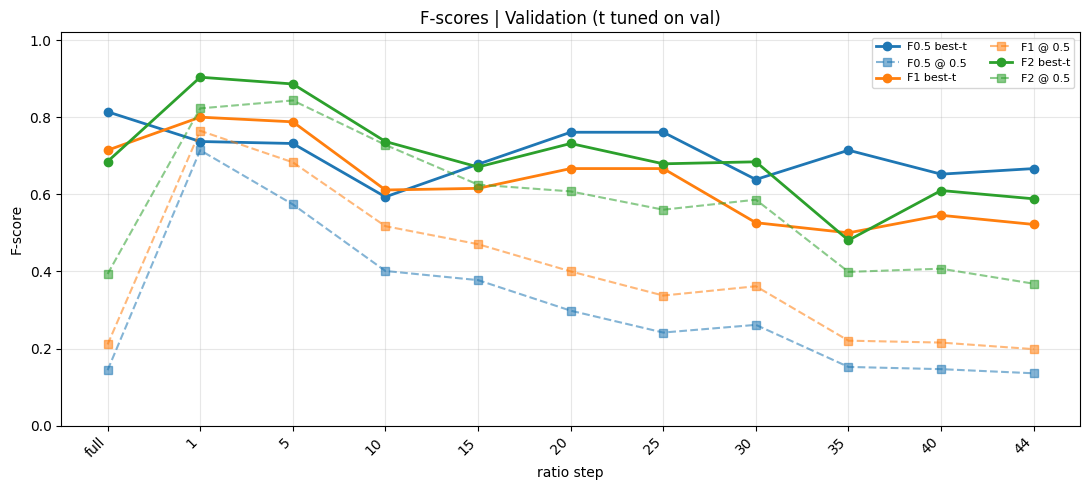

Saved: /kaggle/working/vlst_fp_followup_output/fp_followup_curves_holdout_split_a.png


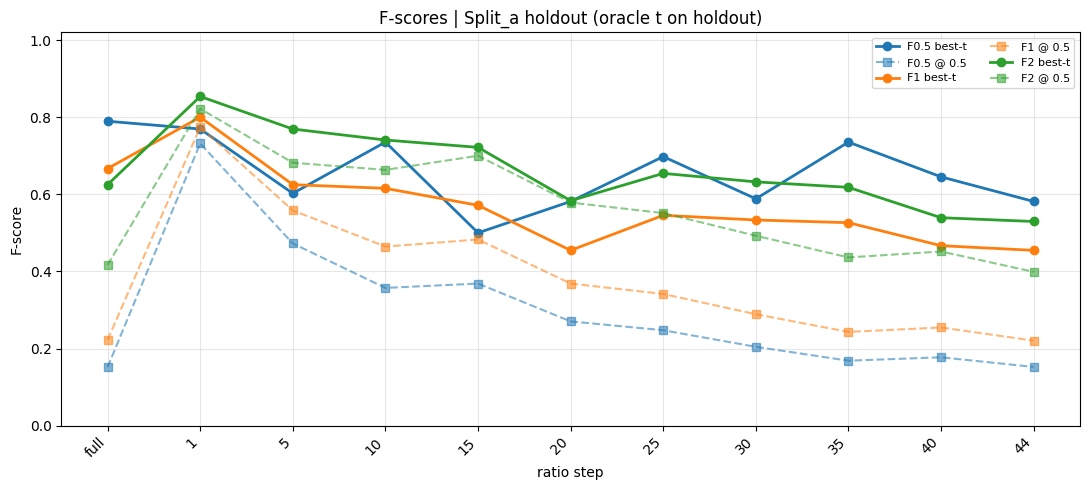

Saved: /kaggle/working/vlst_fp_followup_output/fp_followup_curves_split_b_val.png


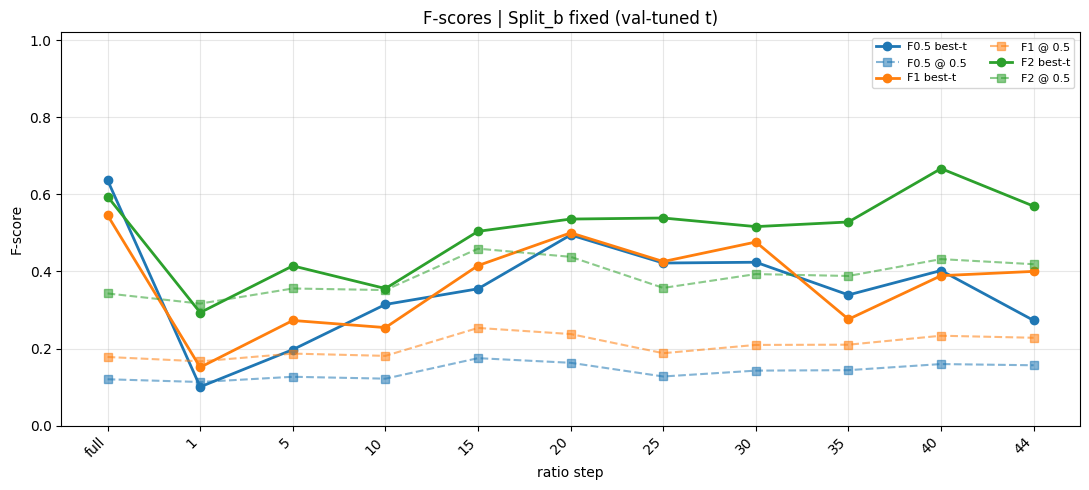

Saved: /kaggle/working/vlst_fp_followup_output/fp_followup_curves_split_b_holdout.png


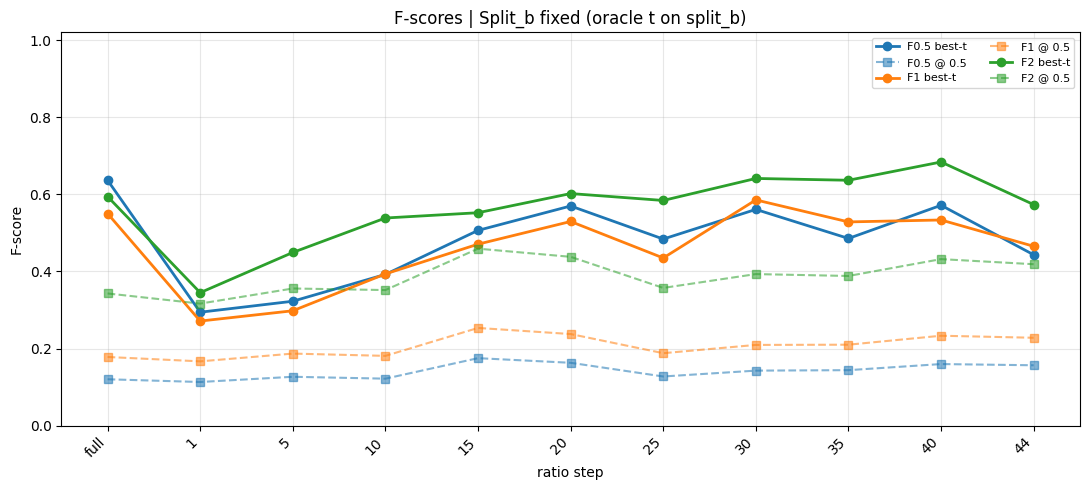

--- FP / FN curves ---
Saved: /kaggle/working/vlst_fp_followup_output/fp_followup_errors_validation.png


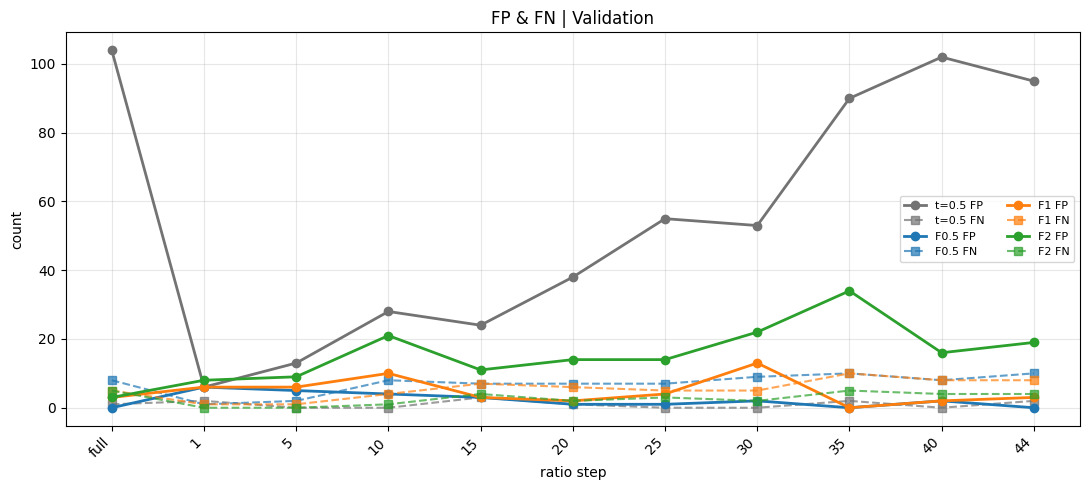

Saved: /kaggle/working/vlst_fp_followup_output/fp_followup_errors_holdout_split_a.png


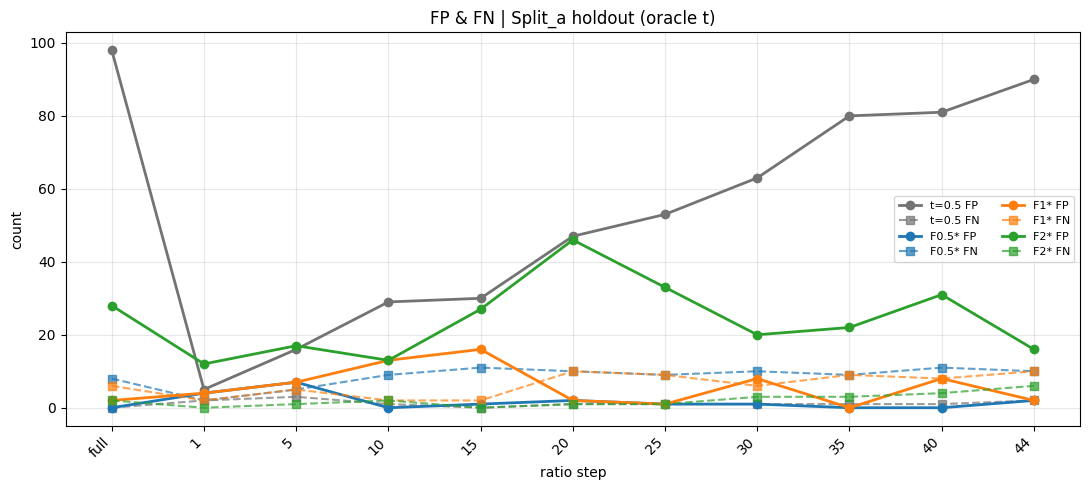

Saved: /kaggle/working/vlst_fp_followup_output/fp_followup_errors_split_b_val.png


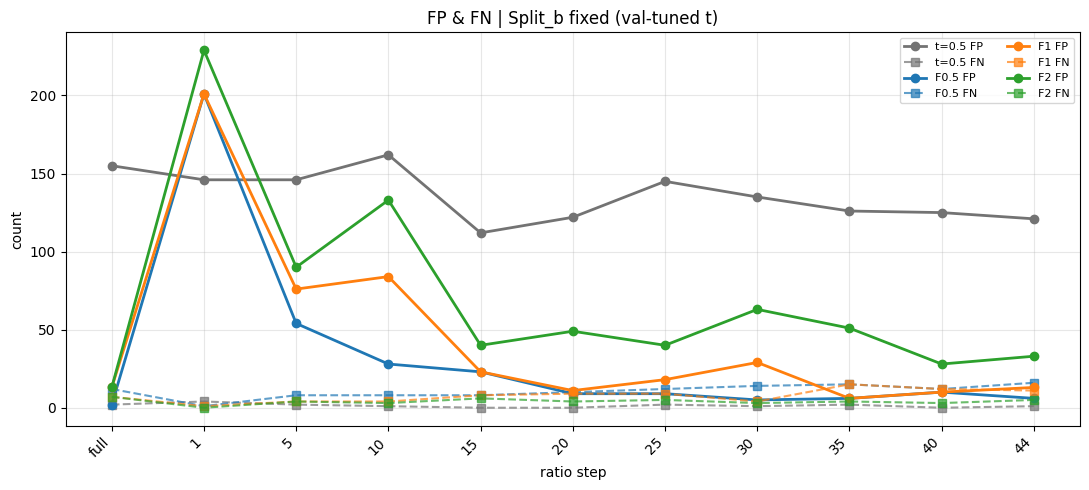

Saved: /kaggle/working/vlst_fp_followup_output/fp_followup_errors_split_b_holdout.png


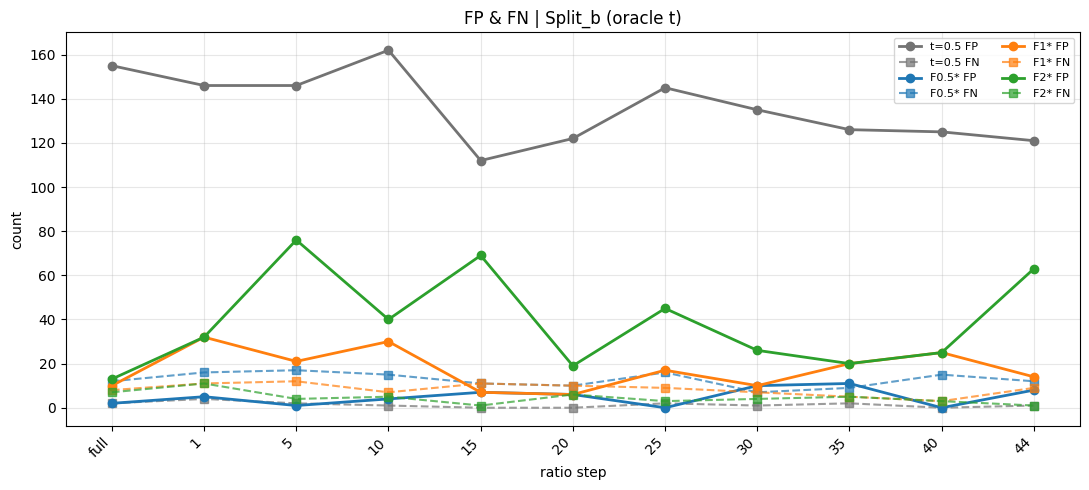

--- AUC curves ---
Saved: /kaggle/working/vlst_fp_followup_output/fp_followup_auc_validation.png


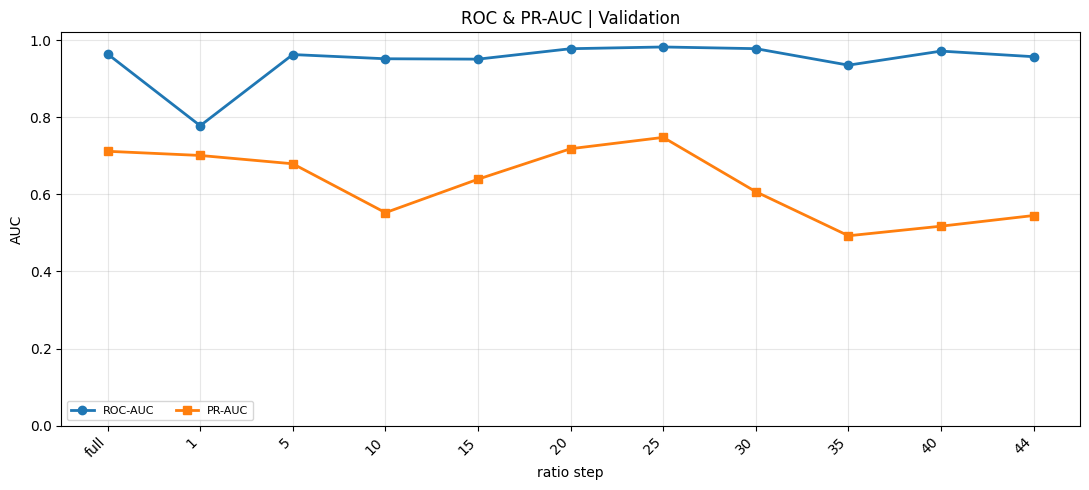

Saved: /kaggle/working/vlst_fp_followup_output/fp_followup_auc_holdout_split_a.png


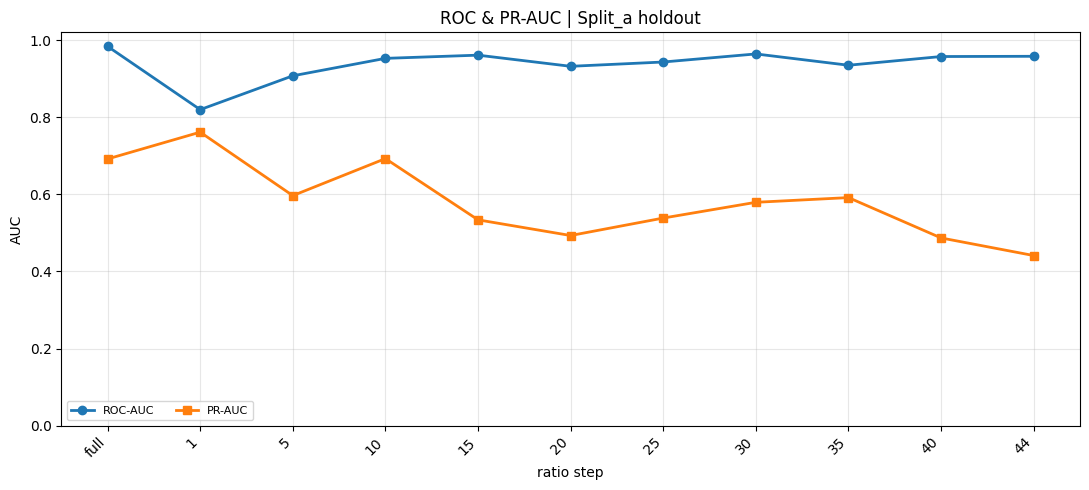

Saved: /kaggle/working/vlst_fp_followup_output/fp_followup_auc_split_b.png


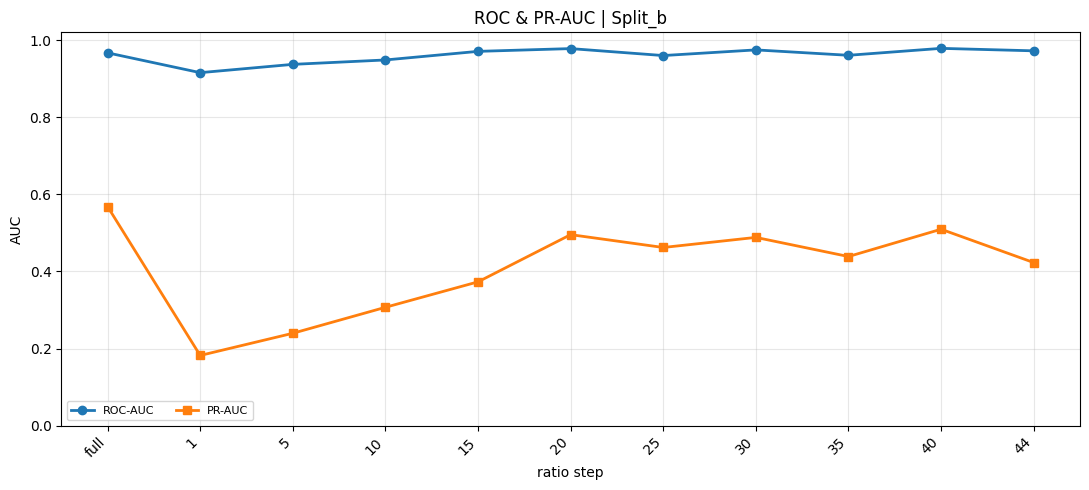

In [7]:
import matplotlib.pyplot as plt

try:
    _ = len(sweep_df)
except NameError:
    sweep_df = pd.read_csv(os.path.join(OUTPUT_DIR, "fp_followup_ratio_sweep.csv"))

_curve_df = sweep_df.sort_values("ratio_requested").reset_index(drop=True)
_x = np.arange(len(_curve_df))
_xlabels = [
    "full" if k == "full_pool" else str(int(r))
    for k, r in zip(_curve_df["step_kind"], _curve_df["ratio_requested"])
]

# --- F-score panels (solid = best-t, dashed = t 0.5) ---
_F_SCORE_SPECS = [
    (
        [
            ("F0.5", "val_f05_at_t_val", "val_f05_at_t05", "C0"),
            ("F1", "val_f1_at_t_val_f1", "val_f1_at_t05", "C1"),
            ("F2", "val_f2_at_t_val_f2", "val_f2_at_t05", "C2"),
        ],
        "F-scores | Validation (t tuned on val)",
        "fp_followup_curves_validation.png",
    ),
    (
        [
            ("F0.5", "hold_f05_at_t_hold", "hold_f05_at_t05", "C0"),
            ("F1", "hold_f1_at_t_hold_f1", "hold_f1_at_t05", "C1"),
            ("F2", "hold_f2_at_t_hold_f2", "hold_f2_at_t05", "C2"),
        ],
        "F-scores | Split_a holdout (oracle t on holdout)",
        "fp_followup_curves_holdout_split_a.png",
    ),
    (
        [
            ("F0.5", "b_tval_f05", "b_t05_f05", "C0"),
            ("F1", "b_tval_f1_f1", "b_t05_f1", "C1"),
            ("F2", "b_tval_f2_f2", "b_t05_f2", "C2"),
        ],
        "F-scores | Split_b fixed (val-tuned t)",
        "fp_followup_curves_split_b_val.png",
    ),
    (
        [
            ("F0.5", "b_hold_f05_at_oracle", "b_hold_f05_at_t05", "C0"),
            ("F1", "b_hold_f1_at_oracle", "b_hold_f1_at_t05", "C1"),
            ("F2", "b_hold_f2_at_oracle", "b_hold_f2_at_t05", "C2"),
        ],
        "F-scores | Split_b fixed (oracle t on split_b)",
        "fp_followup_curves_split_b_holdout.png",
    ),
]

# --- FP / FN panels: (label, fp_col, fn_col, color) ---
_ERROR_SPECS = [
    (
        [
            ("t=0.5", "val_t05_fp", "val_t05_fn", "0.45"),
            ("F0.5", "val_tval_fp", "val_tval_fn", "C0"),
            ("F1", "val_tval_f1_fp", "val_tval_f1_fn", "C1"),
            ("F2", "val_tval_f2_fp", "val_tval_f2_fn", "C2"),
        ],
        "FP & FN | Validation",
        "fp_followup_errors_validation.png",
    ),
    (
        [
            ("t=0.5", "a_t05_cm01", "a_t05_cm10", "0.45"),
            ("F0.5*", "a_thold_cm01", "a_thold_cm10", "C0"),
            ("F1*", "a_thold_f1_cm01", "a_thold_f1_cm10", "C1"),
            ("F2*", "a_thold_f2_cm01", "a_thold_f2_cm10", "C2"),
        ],
        "FP & FN | Split_a holdout (oracle t)",
        "fp_followup_errors_holdout_split_a.png",
    ),
    (
        [
            ("t=0.5", "b_t05_cm01", "b_t05_cm10", "0.45"),
            ("F0.5", "b_tval_cm01", "b_tval_cm10", "C0"),
            ("F1", "b_tval_f1_cm01", "b_tval_f1_cm10", "C1"),
            ("F2", "b_tval_f2_cm01", "b_tval_f2_cm10", "C2"),
        ],
        "FP & FN | Split_b fixed (val-tuned t)",
        "fp_followup_errors_split_b_val.png",
    ),
    (
        [
            ("t=0.5", "b_t05_cm01", "b_t05_cm10", "0.45"),
            ("F0.5*", "b_thold_b_cm01", "b_thold_b_cm10", "C0"),
            ("F1*", "b_thold_b_f1_cm01", "b_thold_b_f1_cm10", "C1"),
            ("F2*", "b_thold_b_f2_cm01", "b_thold_b_f2_cm10", "C2"),
        ],
        "FP & FN | Split_b (oracle t)",
        "fp_followup_errors_split_b_holdout.png",
    ),
]

# --- AUC panels ---
_AUC_SPECS = [
    ("val_roc_auc", "val_pr_auc", "ROC & PR-AUC | Validation", "fp_followup_auc_validation.png"),
    ("hold_a_roc_auc", "hold_a_pr_auc", "ROC & PR-AUC | Split_a holdout", "fp_followup_auc_holdout_split_a.png"),
    ("split_b_roc_auc", "split_b_pr_auc", "ROC & PR-AUC | Split_b", "fp_followup_auc_split_b.png"),
]


def _save_show(fig, save_name):
    out = os.path.join(OUTPUT_DIR, save_name)
    fig.savefig(out, dpi=150, bbox_inches="tight")
    print("Saved:", out)
    plt.show()


def _style_ratio_axis(ax, ylabel, title):
    ax.set_xticks(_x)
    ax.set_xticklabels(_xlabels, rotation=45, ha="right")
    ax.set_xlabel("ratio step")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(loc="best", fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)


def _plot_f_curves(series, title, save_name):
    fig, ax = plt.subplots(figsize=(11, 5))
    for name, col_best, col_05, color in series:
        if col_best not in _curve_df.columns:
            raise KeyError(f"Missing {col_best!r} — re-run §3 before §5")
        ax.plot(_x, _curve_df[col_best], "o-", color=color, linewidth=2, label=f"{name} best-t")
        ax.plot(
            _x, _curve_df[col_05], "s--", color=color, alpha=0.55, linewidth=1.5, label=f"{name} @ 0.5"
        )
    ax.set_ylim(0, 1.02)
    _style_ratio_axis(ax, "F-score", title)
    fig.tight_layout()
    _save_show(fig, save_name)


def _plot_fp_fn(series, title, save_name):
    fig, ax = plt.subplots(figsize=(11, 5))
    for label, col_fp, col_fn, color in series:
        for col in (col_fp, col_fn):
            if col not in _curve_df.columns:
                raise KeyError(f"Missing {col!r} — re-run §3 before §5")
        ax.plot(_x, _curve_df[col_fp], "o-", color=color, linewidth=2, label=f"{label} FP")
        ax.plot(
            _x, _curve_df[col_fn], "s--", color=color, alpha=0.7, linewidth=1.5, label=f"{label} FN"
        )
    _style_ratio_axis(ax, "count", title)
    fig.tight_layout()
    _save_show(fig, save_name)


def _plot_auc(roc_col, pr_col, title, save_name):
    if roc_col not in _curve_df.columns:
        raise KeyError(f"Missing {roc_col!r} — re-run §3 before §5")
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(_x, _curve_df[roc_col], "o-", color="C0", linewidth=2, label="ROC-AUC")
    ax.plot(_x, _curve_df[pr_col], "s-", color="C1", linewidth=2, label="PR-AUC")
    ax.set_ylim(0, 1.02)
    _style_ratio_axis(ax, "AUC", title)
    fig.tight_layout()
    _save_show(fig, save_name)


print("--- F-score curves ---")
for spec, title, fname in _F_SCORE_SPECS:
    _plot_f_curves(spec, title, fname)

print("--- FP / FN curves ---")
for spec, title, fname in _ERROR_SPECS:
    _plot_fp_fn(spec, title, fname)

print("--- AUC curves ---")
for roc_c, pr_c, title, fname in _AUC_SPECS:
    _plot_auc(roc_c, pr_c, title, fname)


## 5. Saved artifact paths


In [8]:
print(
    "Artifacts written to:",
    OUTPUT_DIR,
    "\n",
    " - fp_followup_ratio_sweep.csv",
)


Artifacts written to: /kaggle/working/vlst_fp_followup_output 
  - fp_followup_ratio_sweep.csv
